## Projekt 3: Atraktoret Lorenz dhe Rossler,ndjeshmeria ndaj kushteve fillestare.

**Studenti:** Erik Cupi

**Lenda:** Modelim ne Fizike



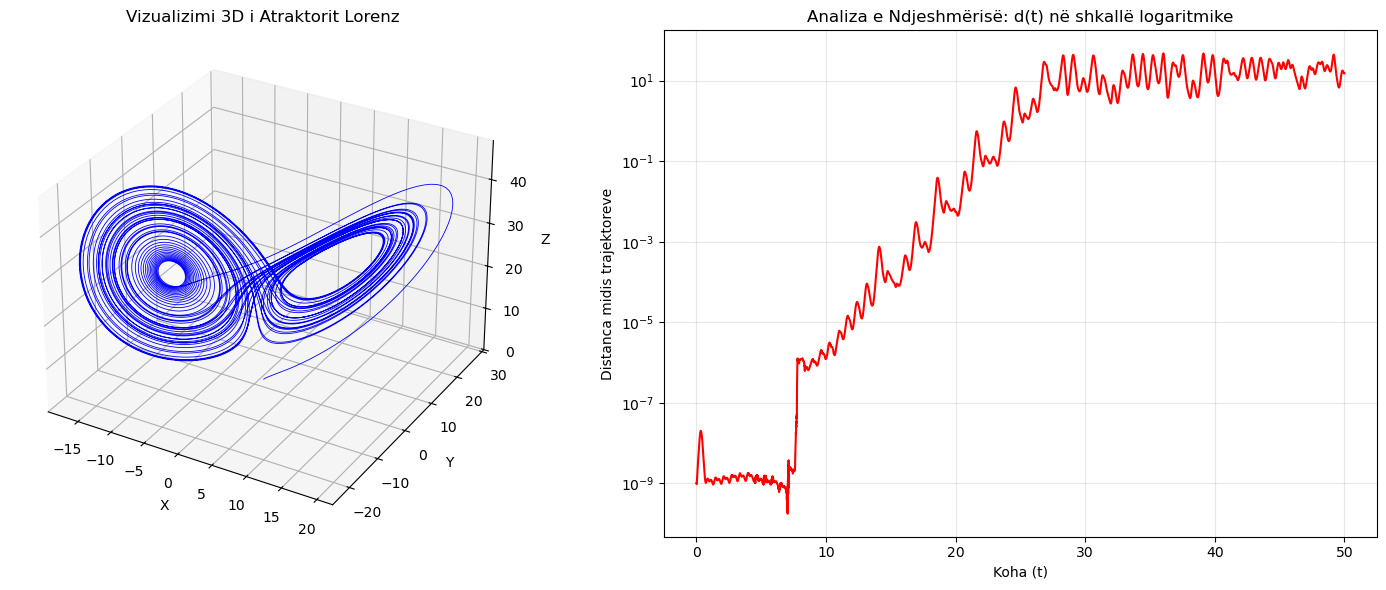

--------------------------------------------------
DISKUTIMI MBI PROVËN E KAOSIT:
Distanca fillestare: 1e-09
Distanca pas t=50: 15.2031
Përfundim: Grafiku i dytë vërteton kaosin përmes divergjencës eksponenciale,
duke treguar se vizualizimi 3D është vetëm një pjesë e analizës.
--------------------------------------------------


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Implementimi i Sistemit Lorenz (Hapi 1)
def lorenz(s, t, sigma=10, rho=28, beta=8/3):
    x, y, z = s
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

# Parametrat e simulimit
t = np.linspace(0, 50, 10000)
delta_0 = 1e-9  # Diferenca fillestare (Hapi 3)

# Simulimi i dy kushteve fillestare
sol1 = odeint(lorenz, [1.0, 1.0, 1.0], t)
sol2 = odeint(lorenz, [1.0 + delta_0, 1.0, 1.0], t)

# Krijimi i figurës me 2 grafikë (Hapi 2 dhe 3)
fig = plt.figure(figsize=(15, 6))

# GRAFIKU 1: Trajektorja 3D (Hapi 2)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(sol1[:, 0], sol1[:, 1], sol1[:, 2], lw=0.6, color='blue', label='Trajektorja A')
ax1.set_title("Vizualizimi 3D i Atraktorit Lorenz")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

# GRAFIKU 2: Rritja e distancës d(t) (Hapi 3)
ax2 = fig.add_subplot(1, 2, 2)
distanca = np.sqrt(np.sum((sol1 - sol2)**2, axis=1))
ax2.semilogy(t, distanca, color='red', lw=1.5)
ax2.set_title("Analiza e Ndjeshmërisë: d(t) në shkallë logaritmike")
ax2.set_xlabel("Koha (t)")
ax2.set_ylabel("Distanca midis trajektoreve")
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# Hapi 5: Diskutimi i shkurtër (Output)
print("-" * 50)
print("DISKUTIMI MBI PROVËN E KAOSIT:")
print(f"Distanca fillestare: {delta_0}")
print(f"Distanca pas t=50: {distanca[-1]:.4f}")
print("Përfundim: Grafiku i dytë vërteton kaosin përmes divergjencës eksponenciale,")
print("duke treguar se vizualizimi 3D është vetëm një pjesë e analizës.")
print("-" * 50)